## Exploratory Data Analysis (EDA)

Dataset: Titanic – Passenger Survival Dataset

This notebook performs a complete EDA workflow:


*   Load and inspect the dataset

* Check data quality (types, missing values, duplicates)

* Summary statistics

* Univariate analysis (distributions)

* Bivariate analysis vs. target (Survived)

* Correlation analysis

 Key insights & conclusions
Target column: Survived (1 = survived, 0 = did not survive)



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 1. Dataset overview

In [2]:
df.shape


(891, 12)

In [3]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Column meaning (quick guide)



*   PassengerId: Unique passenger identifier

* Survived: Target variable (1 = survived, 0 = did not
survive)

* Pclass: Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)

* Name: Passenger name

* Sex: Gender

* Age: Age in years

* SibSp: Number of siblings/spouses aboard

* Parch: Number of parents/children aboard

* Ticket: Ticket number

* Fare: Ticket fare

* Cabin: Cabin number

* Embarked: Port of embarkation



# 2. Data quality checks
Missing values

In [5]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


Duplicate rows


In [6]:
df.duplicated().sum()

np.int64(0)

## Observation

This dataset contains 891 passenger records and 12 features.

* Age contains 177 missing values.

* Cabin contains 687 missing values.

* Embarked contains 2 missing values.

* No duplicate rows were detected.

Cabin has a large proportion of missing data and may not be reliable for modeling.

# 3. Summary statistics

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


### Target balance

In [8]:
survival_counts = df["Survived"].value_counts().sort_index()
survival_counts, survival_counts / len(df)

(Survived
 0    549
 1    342
 Name: count, dtype: int64,
 Survived
 0    0.616162
 1    0.383838
 Name: count, dtype: float64)

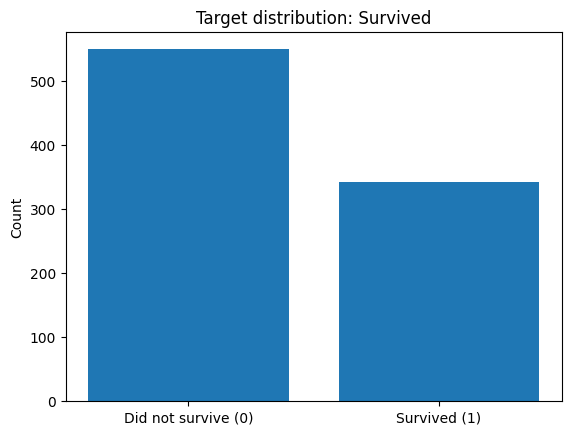

In [9]:
plt.figure()
plt.bar(["Did not survive (0)", "Survived (1)"], survival_counts.values)
plt.title("Target distribution: Survived")
plt.ylabel("Count")
plt.show()

### Observation

The target variable is moderately imbalanced.
Approximately 62% of passengers did not survive, while 38% survived.

# 4. Univariate analysis (single-variable)
Numeric features

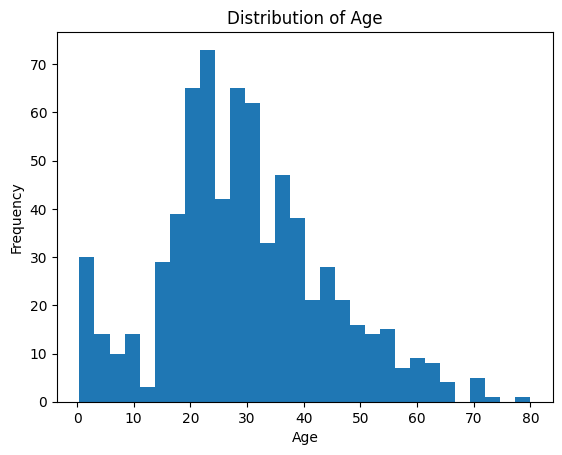

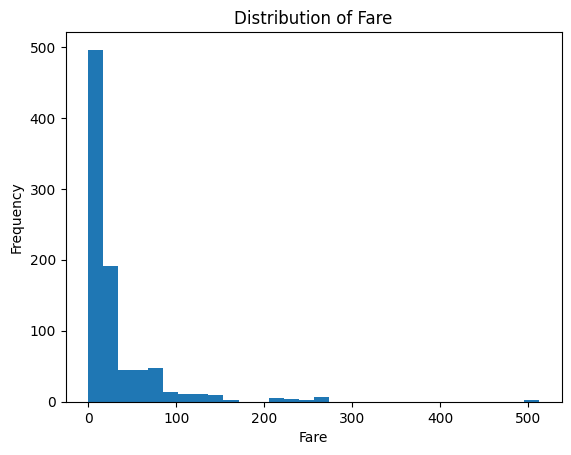

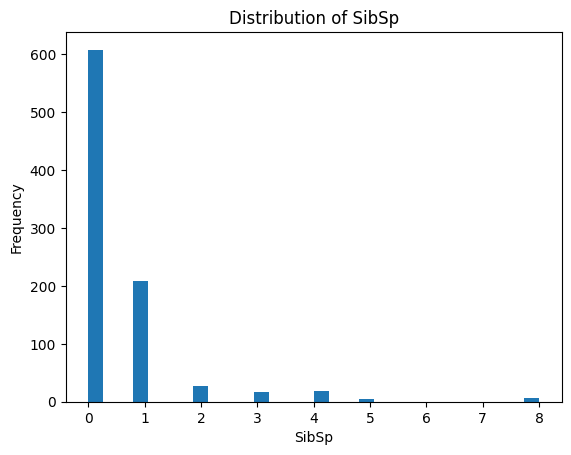

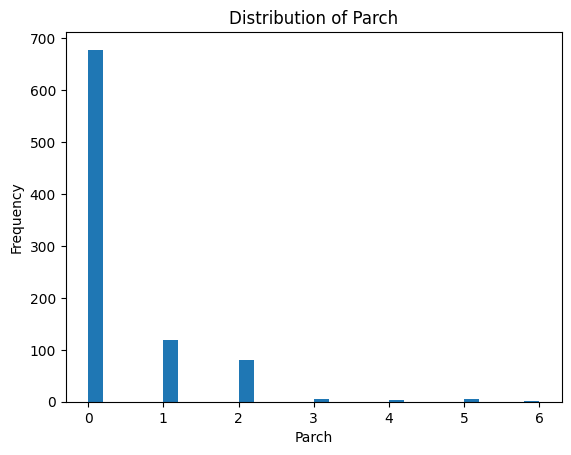

In [10]:
numeric_cols = ["Age","Fare","SibSp","Parch"]

for col in numeric_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

### Categorical features

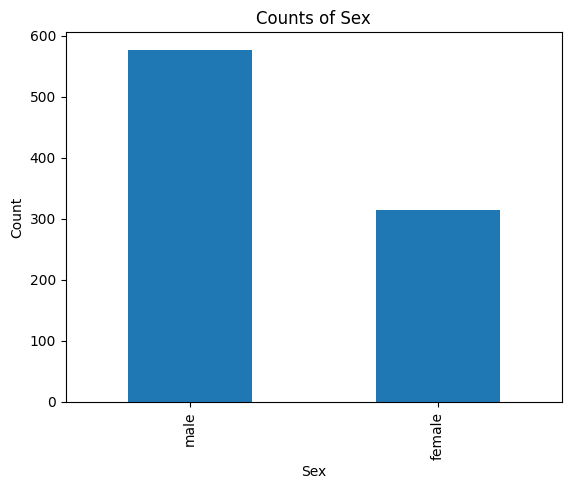

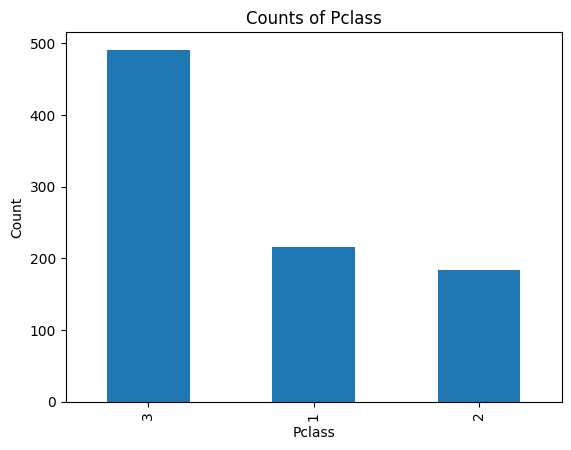

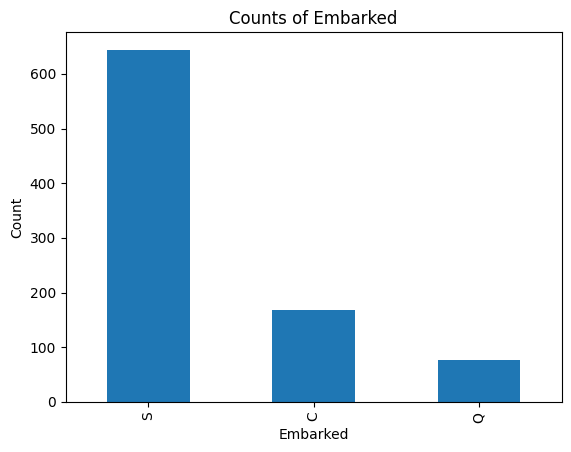

In [11]:
cat_cols = ["Sex","Pclass","Embarked"]

for col in cat_cols:
    vc = df[col].value_counts()
    plt.figure()
    vc.plot(kind="bar")
    plt.title(f"Counts of {col}")
    plt.ylabel("Count")
    plt.show()

### Observation

* Age distribution shows most passengers were between 20–40 years old.

* Fare distribution is highly right-skewed.

* Most passengers were in 3rd class.

# 5. Bivariate analysis vs outcome (Survived)
Numeric features vs survival

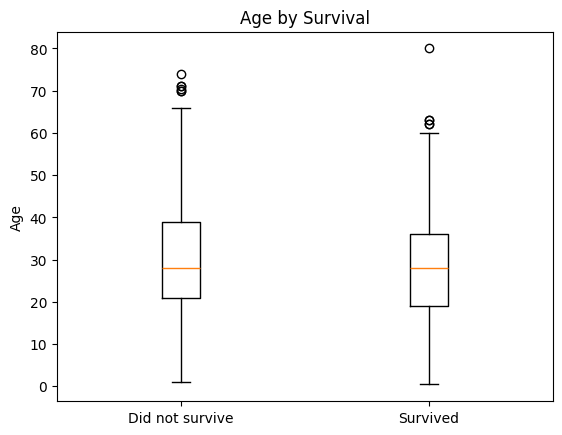

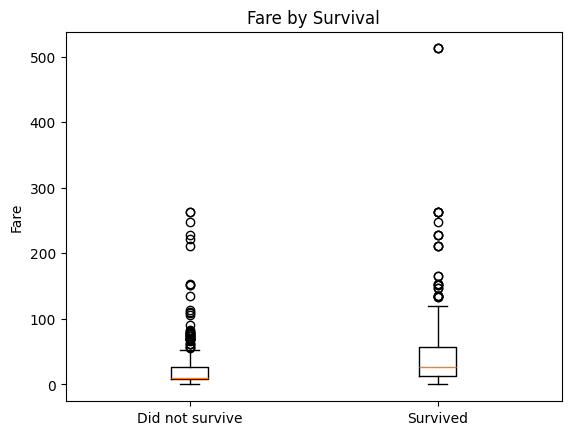

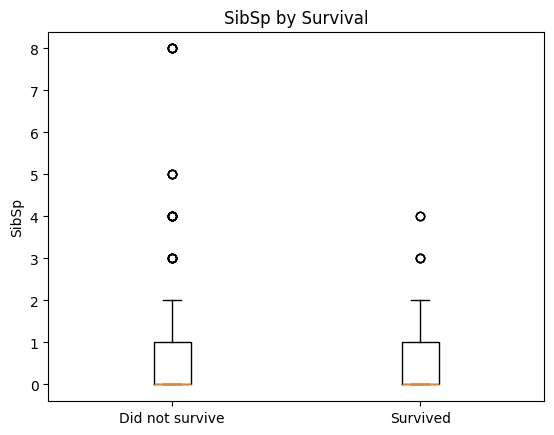

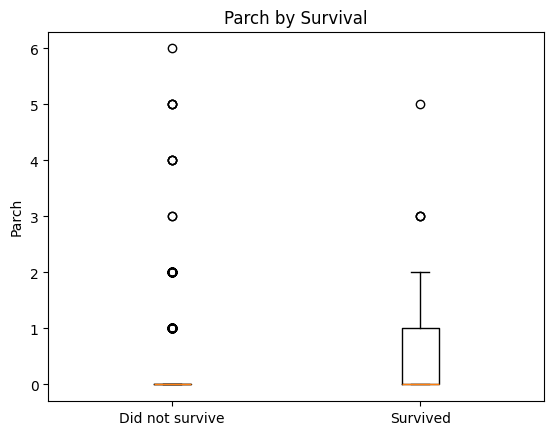

In [12]:
for col in numeric_cols:
    plt.figure()
    data0 = df[df["Survived"]==0][col]
    data1 = df[df["Survived"]==1][col]
    plt.boxplot([data0.dropna(), data1.dropna()],
                tick_labels=["Did not survive", "Survived"])
    plt.title(f"{col} by Survival")
    plt.ylabel(col)
    plt.show()

### Categorical features vs survival rate

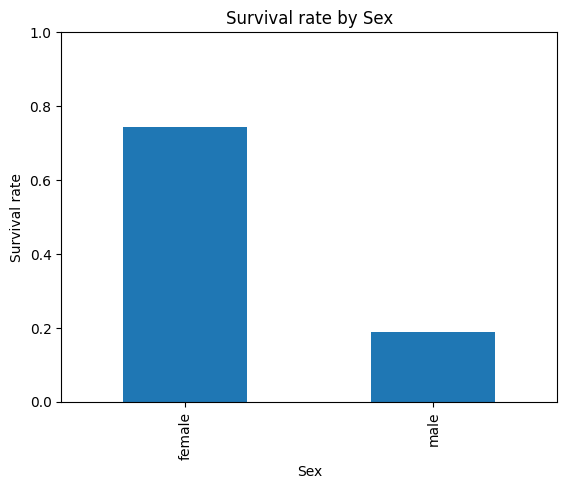

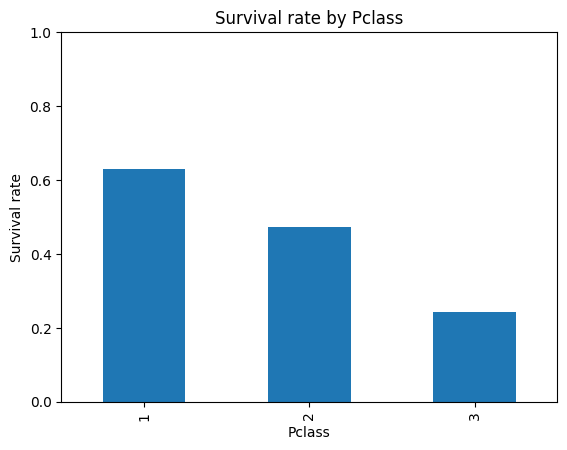

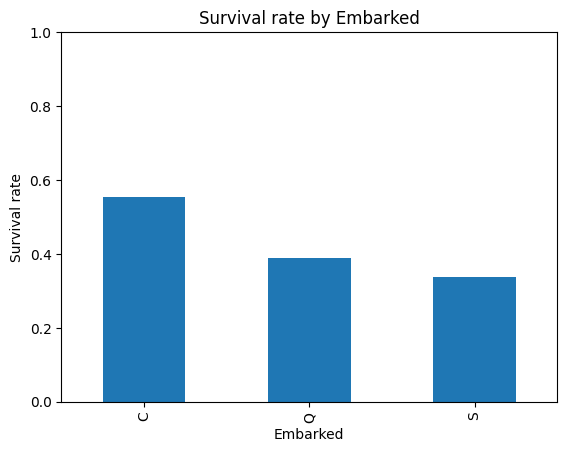

In [13]:
for col in cat_cols:
    rate = df.groupby(col)["Survived"].mean()
    plt.figure()
    rate.plot(kind="bar")
    plt.title(f"Survival rate by {col}")
    plt.ylabel("Survival rate")
    plt.ylim(0,1)
    plt.show()

### Observation

* Females had a significantly higher survival rate than males.

* First-class passengers survived more frequently than third-class passengers.

* Higher fare values are associated with increased survival probability.

* Age shows weaker differences compared to gender and passenger class.

# 6. Correlation analysis

In [14]:
corr = df.corr(numeric_only=True)
corr

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


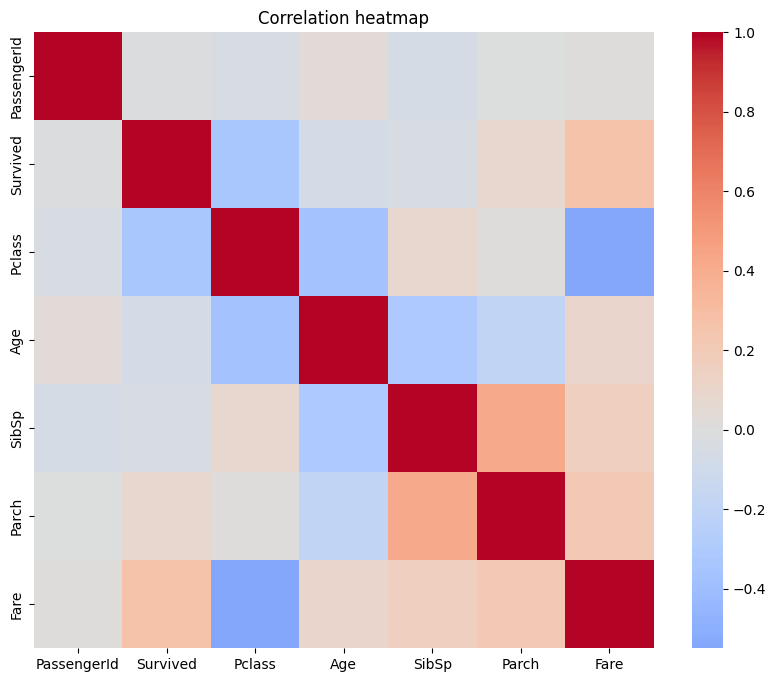

In [15]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.show()

### Top correlations with the target

In [16]:
target_corr = corr["Survived"].sort_values()
target_corr

,Survived
Pclass,-0.338481
Age,-0.077221
SibSp,-0.035322
PassengerId,-0.005007
Parch,0.081629
Fare,0.257307
Survived,1.000000


In [17]:
top_abs = target_corr.drop("Survived").abs().sort_values(ascending=False).head(6)
top_abs

,Survived
Pclass,0.338481
Fare,0.257307
Parch,0.081629
Age,0.077221
SibSp,0.035322
PassengerId,0.005007


### Observation

* Pclass shows negative correlation with survival.

* Fare shows positive correlation with survival.

* Age shows weak correlation.

No single numeric feature fully explains survival, but several show moderate relationships.

# 7. Key insights
### Data quality

* Missing values exist mainly in Age and Cabin.

* No duplicate records were found.

### Target balance

* Survival rate is approximately 38%.

### Strongest predictors (from correlation + plots)

* Gender (Sex)

* Passenger class (Pclass)

* Fare

### Weaker predictors

* Age

* Family-related features (SibSp, Parch)

# 8. Conclusion

This EDA explored the Titanic passenger dataset and analyzed distributions, group differences, and correlations with survival.

The analysis indicates that survival was strongly influenced by gender and socio-economic status (passenger class and fare).

The dataset contains missing values that must be handled before predictive modeling.

These insights provide a strong foundation for building a classification model to predict passenger survival.